**Implementación de modelos supervisados (regresión) con Scikit-learn.**

### Importe de librerías necesarias


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree


In [2]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from preprocesamiento.data_preprocessing import corregir_valores_negativos
from preprocesamiento.data_preprocessing import detectar_inconsistencias
from preprocesamiento.data_preprocessing import separar_objetivo_features
from preprocesamiento.data_preprocessing import eliminar_nulos_objetivo
from preprocesamiento.pipelines import aplicar_pipeline_limpieza_train_test
from preprocesamiento.pipelines import build_cleaning_pipeline_reg
from preprocesamiento.pipelines import build_decision_tree_regressor_pipeline
from preprocesamiento.pipelines import build_linear_regression_pipeline
from preprocesamiento.pipelines import build_preprocessor
from model_evaluation import evaluar_regresor
from model_training import entrenar_modelo

### Carga de Datos

In [3]:
url = "https://raw.githubusercontent.com/ramirezluna-david/proyecto_modelado_grp2/rama_david/data/dataset_clientes.csv"
data = pd.read_csv(url)

### Preprocesamiento de datos

#### Detección de inconsistencias

In [4]:
# Detección de inconsistencias: negativos o ceros en columnas que deberían ser positivas.
conteo_negativos, conteo_ceros = detectar_inconsistencias(data)

Negativos detectados: {'ingreso_mensual': 11, 'gasto_mensual': 68, 'deuda_total': 143}
Ceros detectados: ninguno


In [5]:
# Tratamiento: corrige valores negativos convirtiéndolos a valor absoluto.
data = corregir_valores_negativos(data)

Valores negativos corregidos a valores absolutos en las columnas relevantes.


# 1. Modelamiento para variable objetivo "deuda_total"

## Elimina duplicados y separa objetivo/features para mantener alineacion

In [6]:
data_sin_dup, var_dep, var_indep = separar_objetivo_features(
    data,
    target="deuda_total",
 )

## Construcción de arrays para procesamiento

In [7]:
numerical_features = ["gasto_mensual", "score_crediticio", "ingreso_mensual", "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias", "num_productos", "hora_registro"] # Define listado de variables numéricas.
categorical_nominales = ["abandono", "tiene_tarjeta_credito", "genero", "region", "estado_civil", "canal_registro", "dia_semana_registro"] # Define listado de variables categóricas nominales.
categorical_ordinales = ["tipo_plan", "uso_app"] # Define listado de variables categóricas ordinales.
date_time_features = ["fecha_registro"] # Define listado de variables de fecha y hora.
orden_tipo_plan = ["Basico", "Estandar", "Premium"] # Define orden para variable ordinal tipo_plan.
orden_uso_app = ["Bajo", "Medio", "Alto"] # Define orden para variable ordinal uso_app.

## Integración de pipelines de transformación

In [8]:
pipeline_numerical_features, pipeline_nominales, pipeline_ordinales, preprocesador = build_preprocessor(
    numerical_features=numerical_features,
    categorical_nominales=categorical_nominales,
    categorical_ordinales=categorical_ordinales,
    orden_tipo_plan=orden_tipo_plan,
    orden_uso_app=orden_uso_app,
)

## Modelo de LinealRegression para "deuda_total"

### Pipeline para Regresión Lineal

In [9]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para regresión lineal.
pipeline_modelo_lr = build_linear_regression_pipeline()

In [10]:
# Divide en train/test antes de ajustar el pipeline
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    var_indep, var_dep, test_size=0.3, random_state=29
)

# Ajusta el pipeline solo con train y transforma ambos conjuntos
X_train_t, X_test_t = aplicar_pipeline_limpieza_train_test(
    pipeline_limpieza, X_train_raw, X_test_raw
)

X_train_t.head()

,gasto_mensual,score_crediticio,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,canal_registro_Web,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app
0,-0.087045,-1.816641,-0.589979,-1.151663,-1.448151,1.668722,-0.254486,-0.704331,0.376269,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0
1,-1.237125,0.665455,0.867027,0.301419,0.016122,1.302137,-0.483692,0.711409,0.376269,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.694986,0.679260,0.061588,0.357306,1.509680,0.019089,1.302201,0.711409,0.230879,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
3,1.172096,-0.885423,-0.031939,-1.486989,1.656107,0.019089,0.920192,0.711409,-0.641460,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
4,-0.818507,0.858574,-0.503408,-0.425122,1.656107,-1.630545,-1.496016,0.711409,1.103218,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0


In [11]:
target = "deuda_total"
mejores_variables_predictoras = [
    "abandono_0",
    "abandono_1", 
    "num_productos", 
    "dia_semana_registro_Lunes", 
    "hora_registro",
    "dia_semana_registro_Viernes",
    "dia_semana_registro_Jueves",
    "genero_Masculino"
 ]
X_train = X_train_t[mejores_variables_predictoras]
X_test = X_test_t[mejores_variables_predictoras]

### División train/test


In [12]:
# El split ya se hizo antes del fit del pipeline
X_train.shape, X_test.shape

((14000, 8), (6000, 8))

### Entrenamiento


In [13]:
pipeline_modelo_lr = entrenar_modelo(pipeline_modelo_lr, X_train, y_train)

In [14]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_lr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['r2']:.3f}")
print(f"{'MAE':<6}: {metricas['mae']:,.0f}")


--- Métricas del modelo ---


KeyError: 'r2'

In [ ]:
# Variables que fueron eliminadas por presentar colinealidad
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
print(f"Variables eliminadas por colinealidad (n={len(cols_eliminadas)}):")
for col in cols_eliminadas:
    print(f"- {col}")

Variables eliminadas por colinealidad (n=1):
- abandono_1


In [ ]:
# Variables con las cuales fue entrenado el modelo
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
variables_usadas = [c for c in X_train.columns if c not in cols_eliminadas]

print(f"Variables usadas por el modelo (n={len(variables_usadas)}):")
for col in variables_usadas:
    print(f"- {col}")

Variables usadas por el modelo (n=7):
- abandono_0
- num_productos
- dia_semana_registro_Lunes
- hora_registro
- dia_semana_registro_Viernes
- dia_semana_registro_Jueves
- genero_Masculino


## Modelo DecisionTreeRegressor para "deuda_total"

### Pipeline para DecisionTreeRegressor

In [ ]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para DecisionTreeRegressor.
pipeline_modelo_dtr = build_decision_tree_regressor_pipeline(max_depth=7, min_samples_leaf=15, random_state=42)

In [ ]:
# Divide en train/test antes de ajustar el pipeline
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    var_indep, var_dep, test_size=0.3, random_state=29
)

# Ajusta el pipeline solo con train y transforma ambos conjuntos
X_train_t, X_test_t = aplicar_pipeline_limpieza_train_test(
    pipeline_limpieza, X_train_raw, X_test_raw
)

X_train_t.head()

,gasto_mensual,score_crediticio,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,canal_registro_Web,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app
0,-0.087045,-1.816641,-0.589979,-1.151663,-1.448151,1.668722,-0.254486,-0.704331,0.376269,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0
1,-1.237125,0.665455,0.867027,0.301419,0.016122,1.302137,-0.483692,0.711409,0.376269,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.694986,0.679260,0.061588,0.357306,1.509680,0.019089,1.302201,0.711409,0.230879,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
3,1.172096,-0.885423,-0.031939,-1.486989,1.656107,0.019089,0.920192,0.711409,-0.641460,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
4,-0.818507,0.858574,-0.503408,-0.425122,1.656107,-1.630545,-1.496016,0.711409,1.103218,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0


In [ ]:
target = "deuda_total"
mejores_variables_predictoras = [
    "abandono_0",
    "abandono_1", 
    "num_productos", 
    "dia_semana_registro_Lunes", 
    "hora_registro",
    "dia_semana_registro_Viernes",
    "dia_semana_registro_Jueves",
    "genero_Masculino"
 ]
X_train = X_train_t[mejores_variables_predictoras]
X_test = X_test_t[mejores_variables_predictoras]

### División train/test


In [ ]:
# El split ya se hizo antes del fit del pipeline
X_train.shape, X_test.shape

((14000, 8), (6000, 8))

### Entrenamiento

In [ ]:
pipeline_modelo_dtr = entrenar_modelo(pipeline_modelo_dtr, X_train, y_train)

In [ ]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_dtr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['r2']:.3f}")
print(f"{'MAE':<6}: {metricas['mae']:,.0f}")


--- Métricas del modelo ---
R2    : -0.013
MAE   : 700,256


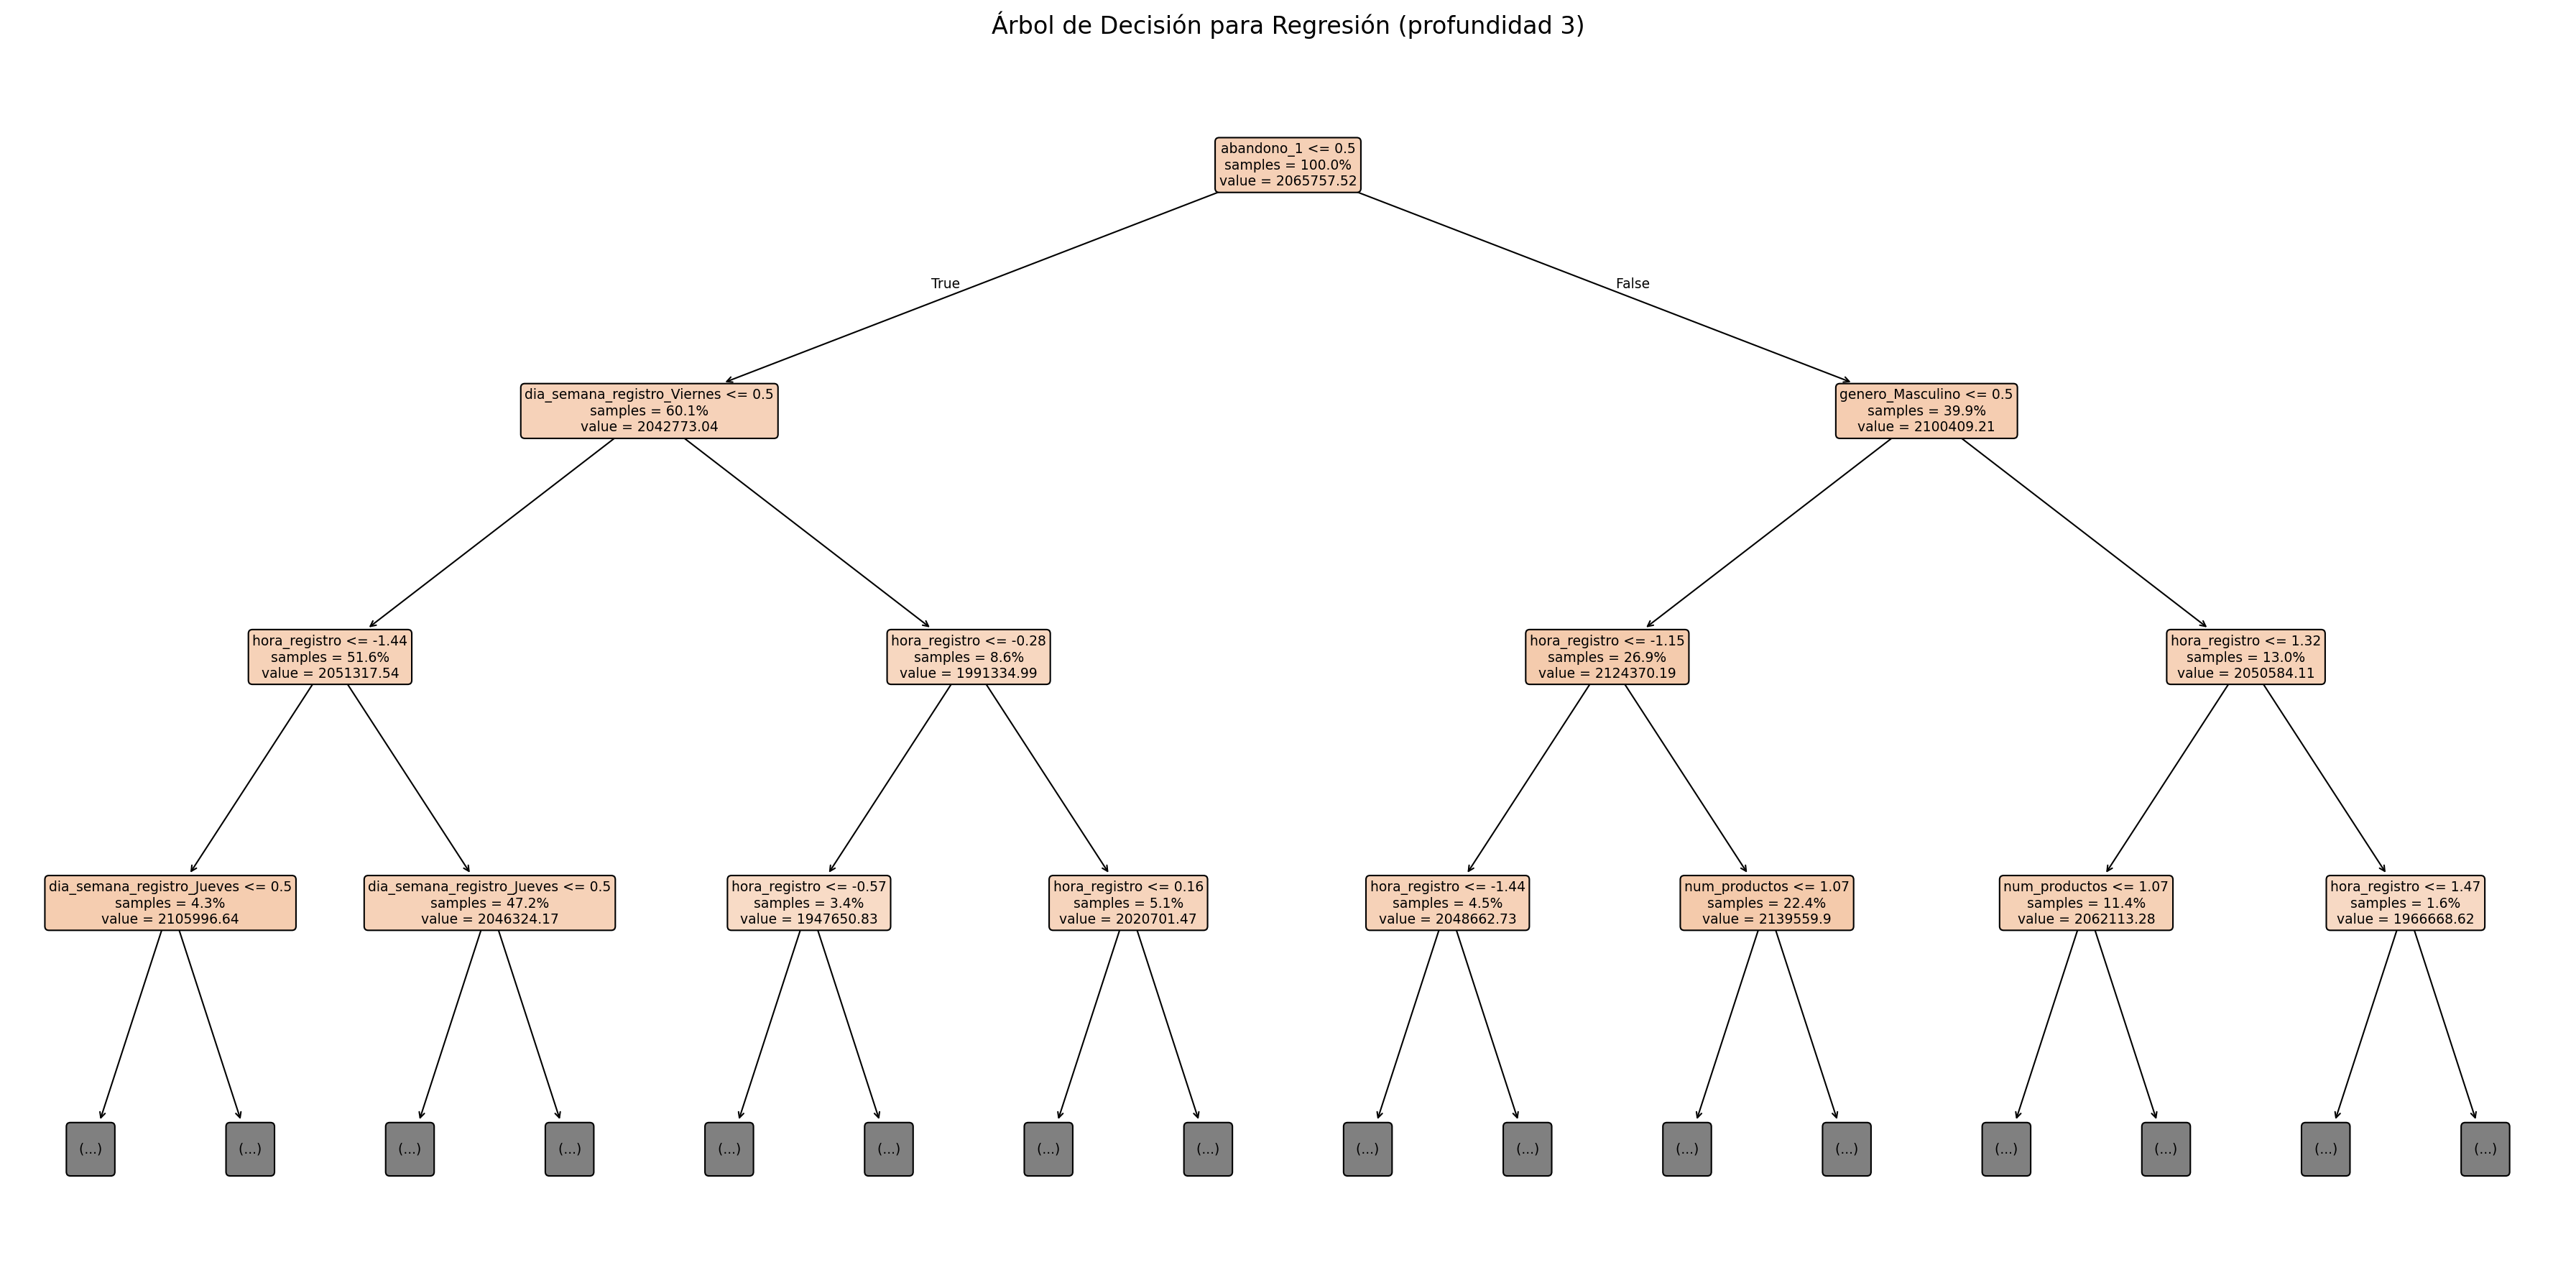

In [ ]:
modelo_arbol = DecisionTreeRegressor(max_depth=7, min_samples_leaf=15, random_state=42)
modelo_arbol = modelo_arbol.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(24, 12), dpi=150)
plot_tree(
    modelo_arbol,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3,
    impurity=False,
    proportion=True,
    precision=2,
    ax=ax,
 )

ax.set_title("Árbol de Decisión para Regresión (profundidad 3)", fontsize=16)
fig.tight_layout()
plt.show()

# 2. Modelamiento para variable objetivo "gasto_mensual"

## Elimina duplicados y separa objetivo/features para mantener alineacion

In [ ]:
data_filtrada = eliminar_nulos_objetivo(data, target="gasto_mensual")
data_sin_dup, var_dep, var_indep = separar_objetivo_features(
    data_filtrada,
    target="gasto_mensual",
 )

In [ ]:
# Verifica que no haya nulos en la variable objetivo
var_dep.isna().sum()

np.int64(0)

## Construcción de arrays para procesamiento

In [ ]:
numerical_features = ["deuda_total", "score_crediticio", "ingreso_mensual", "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias", "num_productos", "hora_registro"] # Define listado de variables numéricas.
categorical_nominales = ["abandono", "tiene_tarjeta_credito", "genero", "region", "estado_civil", "canal_registro", "dia_semana_registro"] # Define listado de variables categóricas nominales.
categorical_ordinales = ["tipo_plan", "uso_app"] # Define listado de variables categóricas ordinales.
date_time_features = ["fecha_registro"] # Define listado de variables de fecha y hora.
orden_tipo_plan = ["Basico", "Estandar", "Premium"] # Define orden para variable ordinal tipo_plan.
orden_uso_app = ["Bajo", "Medio", "Alto"] # Define orden para variable ordinal uso_app.

## Integración de pipelines de transformación

In [ ]:
pipeline_numerical_features, pipeline_nominales, pipeline_ordinales, preprocesador = build_preprocessor(
    numerical_features=numerical_features,
    categorical_nominales=categorical_nominales,
    categorical_ordinales=categorical_ordinales,
    orden_tipo_plan=orden_tipo_plan,
    orden_uso_app=orden_uso_app,
)

## Modelo de LinealRegression para "gasto_mensual"

### Pipeline para Regresión Lineal

In [ ]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para regresión lineal.
pipeline_modelo_lr = build_linear_regression_pipeline()

In [ ]:
# Divide en train/test antes de ajustar el pipeline
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    var_indep, var_dep, test_size=0.3, random_state=29
)

# Ajusta el pipeline solo con train y transforma ambos conjuntos
X_train_t, X_test_t = aplicar_pipeline_limpieza_train_test(
    pipeline_limpieza, X_train_raw, X_test_raw
)

X_train_t.head()

,deuda_total,score_crediticio,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,canal_registro_Web,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app
0,-0.006024,-0.564952,-0.725085,-1.252092,-0.146884,0.002178,-0.664779,0.710448,-0.942637,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0
1,1.056188,0.677679,-1.002381,-1.140394,-1.167320,0.002178,-0.037163,1.421698,0.794582,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.344691,-1.571082,0.195988,-0.190961,0.756931,-1.281159,-0.721835,1.421698,-1.087405,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0
3,-0.096538,-0.819964,0.317650,-1.531336,1.398348,1.102181,0.771131,0.710448,1.663191,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0
4,-0.407011,-2.179634,-0.383648,0.088283,-0.263505,-0.914491,-0.712326,1.421698,-0.942637,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [ ]:
target = "gasto_mensual"
mejores_variables_predictoras = [
    "abandono_0",
    "abandono_1",
    "tipo_plan",
    "dia_semana_registro_Viernes", 
    "region_Norte", 
    "canal_registro_App", 
    "dia_semana_registro_Jueves",
    "uso_app",
    "estado_civil_Soltero",
    "region_Sur"
 ]
X_train = X_train_t[mejores_variables_predictoras]
X_test = X_test_t[mejores_variables_predictoras]

### División train/test


In [ ]:
# El split ya se hizo antes del fit del pipeline
X_train.shape, X_test.shape

((13300, 10), (5700, 10))

### Entrenamiento


In [ ]:
pipeline_modelo_lr = entrenar_modelo(pipeline_modelo_lr, X_train, y_train)

In [ ]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_lr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['r2']:.3f}")
print(f"{'MAE':<6}: {metricas['mae']:,.0f}")


--- Métricas del modelo ---
R2    : 0.001
MAE   : 118,595


In [ ]:
# Variables que fueron eliminadas por presentar colinealidad
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
print(f"Variables eliminadas por colinealidad (n={len(cols_eliminadas)}):")
for col in cols_eliminadas:
    print(f"- {col}")

Variables eliminadas por colinealidad (n=1):
- abandono_1


In [ ]:
# Variables con las cuales fue entrenado el modelo
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
variables_usadas = [c for c in X_train.columns if c not in cols_eliminadas]

print(f"Variables usadas por el modelo (n={len(variables_usadas)}):")
for col in variables_usadas:
    print(f"- {col}")

Variables usadas por el modelo (n=9):
- abandono_0
- tipo_plan
- dia_semana_registro_Viernes
- region_Norte
- canal_registro_App
- dia_semana_registro_Jueves
- uso_app
- estado_civil_Soltero
- region_Sur


## Modelo DecisionTreeRegressor para "gasto_mensual"

### Pipeline para DecisionTreeRegressor

In [ ]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para DecisionTreeRegressor.
pipeline_modelo_dtr = build_decision_tree_regressor_pipeline(max_depth=7, min_samples_leaf=15, random_state=42)

In [ ]:
# Divide en train/test antes de ajustar el pipeline
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    var_indep, var_dep, test_size=0.3, random_state=29
)

# Ajusta el pipeline solo con train y transforma ambos conjuntos
X_train_t, X_test_t = aplicar_pipeline_limpieza_train_test(
    pipeline_limpieza, X_train_raw, X_test_raw
)

X_train_t.head()

,deuda_total,score_crediticio,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,canal_registro_Web,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app
0,-0.006024,-0.564952,-0.725085,-1.252092,-0.146884,0.002178,-0.664779,0.710448,-0.942637,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0
1,1.056188,0.677679,-1.002381,-1.140394,-1.167320,0.002178,-0.037163,1.421698,0.794582,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.344691,-1.571082,0.195988,-0.190961,0.756931,-1.281159,-0.721835,1.421698,-1.087405,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0
3,-0.096538,-0.819964,0.317650,-1.531336,1.398348,1.102181,0.771131,0.710448,1.663191,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0
4,-0.407011,-2.179634,-0.383648,0.088283,-0.263505,-0.914491,-0.712326,1.421698,-0.942637,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [ ]:
target = "gasto_mensual"
mejores_variables_predictoras = [
    "abandono_0",
    "abandono_1",
    "tipo_plan",
    "dia_semana_registro_Viernes", 
    "region_Norte", 
    "canal_registro_App", 
    "dia_semana_registro_Jueves",
    "uso_app",
    "estado_civil_Soltero",
    "region_Sur"
 ]
X_train = X_train_t[mejores_variables_predictoras]
X_test = X_test_t[mejores_variables_predictoras]

### División train/test


In [ ]:
# El split ya se hizo antes del fit del pipeline
X_train.shape, X_test.shape

((13300, 10), (5700, 10))

### Entrenamiento

In [ ]:
pipeline_modelo_dtr = entrenar_modelo(pipeline_modelo_dtr, X_train, y_train)

In [ ]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_dtr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['r2']:.3f}")
print(f"{'MAE':<6}: {metricas['mae']:,.0f}")


--- Métricas del modelo ---
R2    : -0.017
MAE   : 119,653


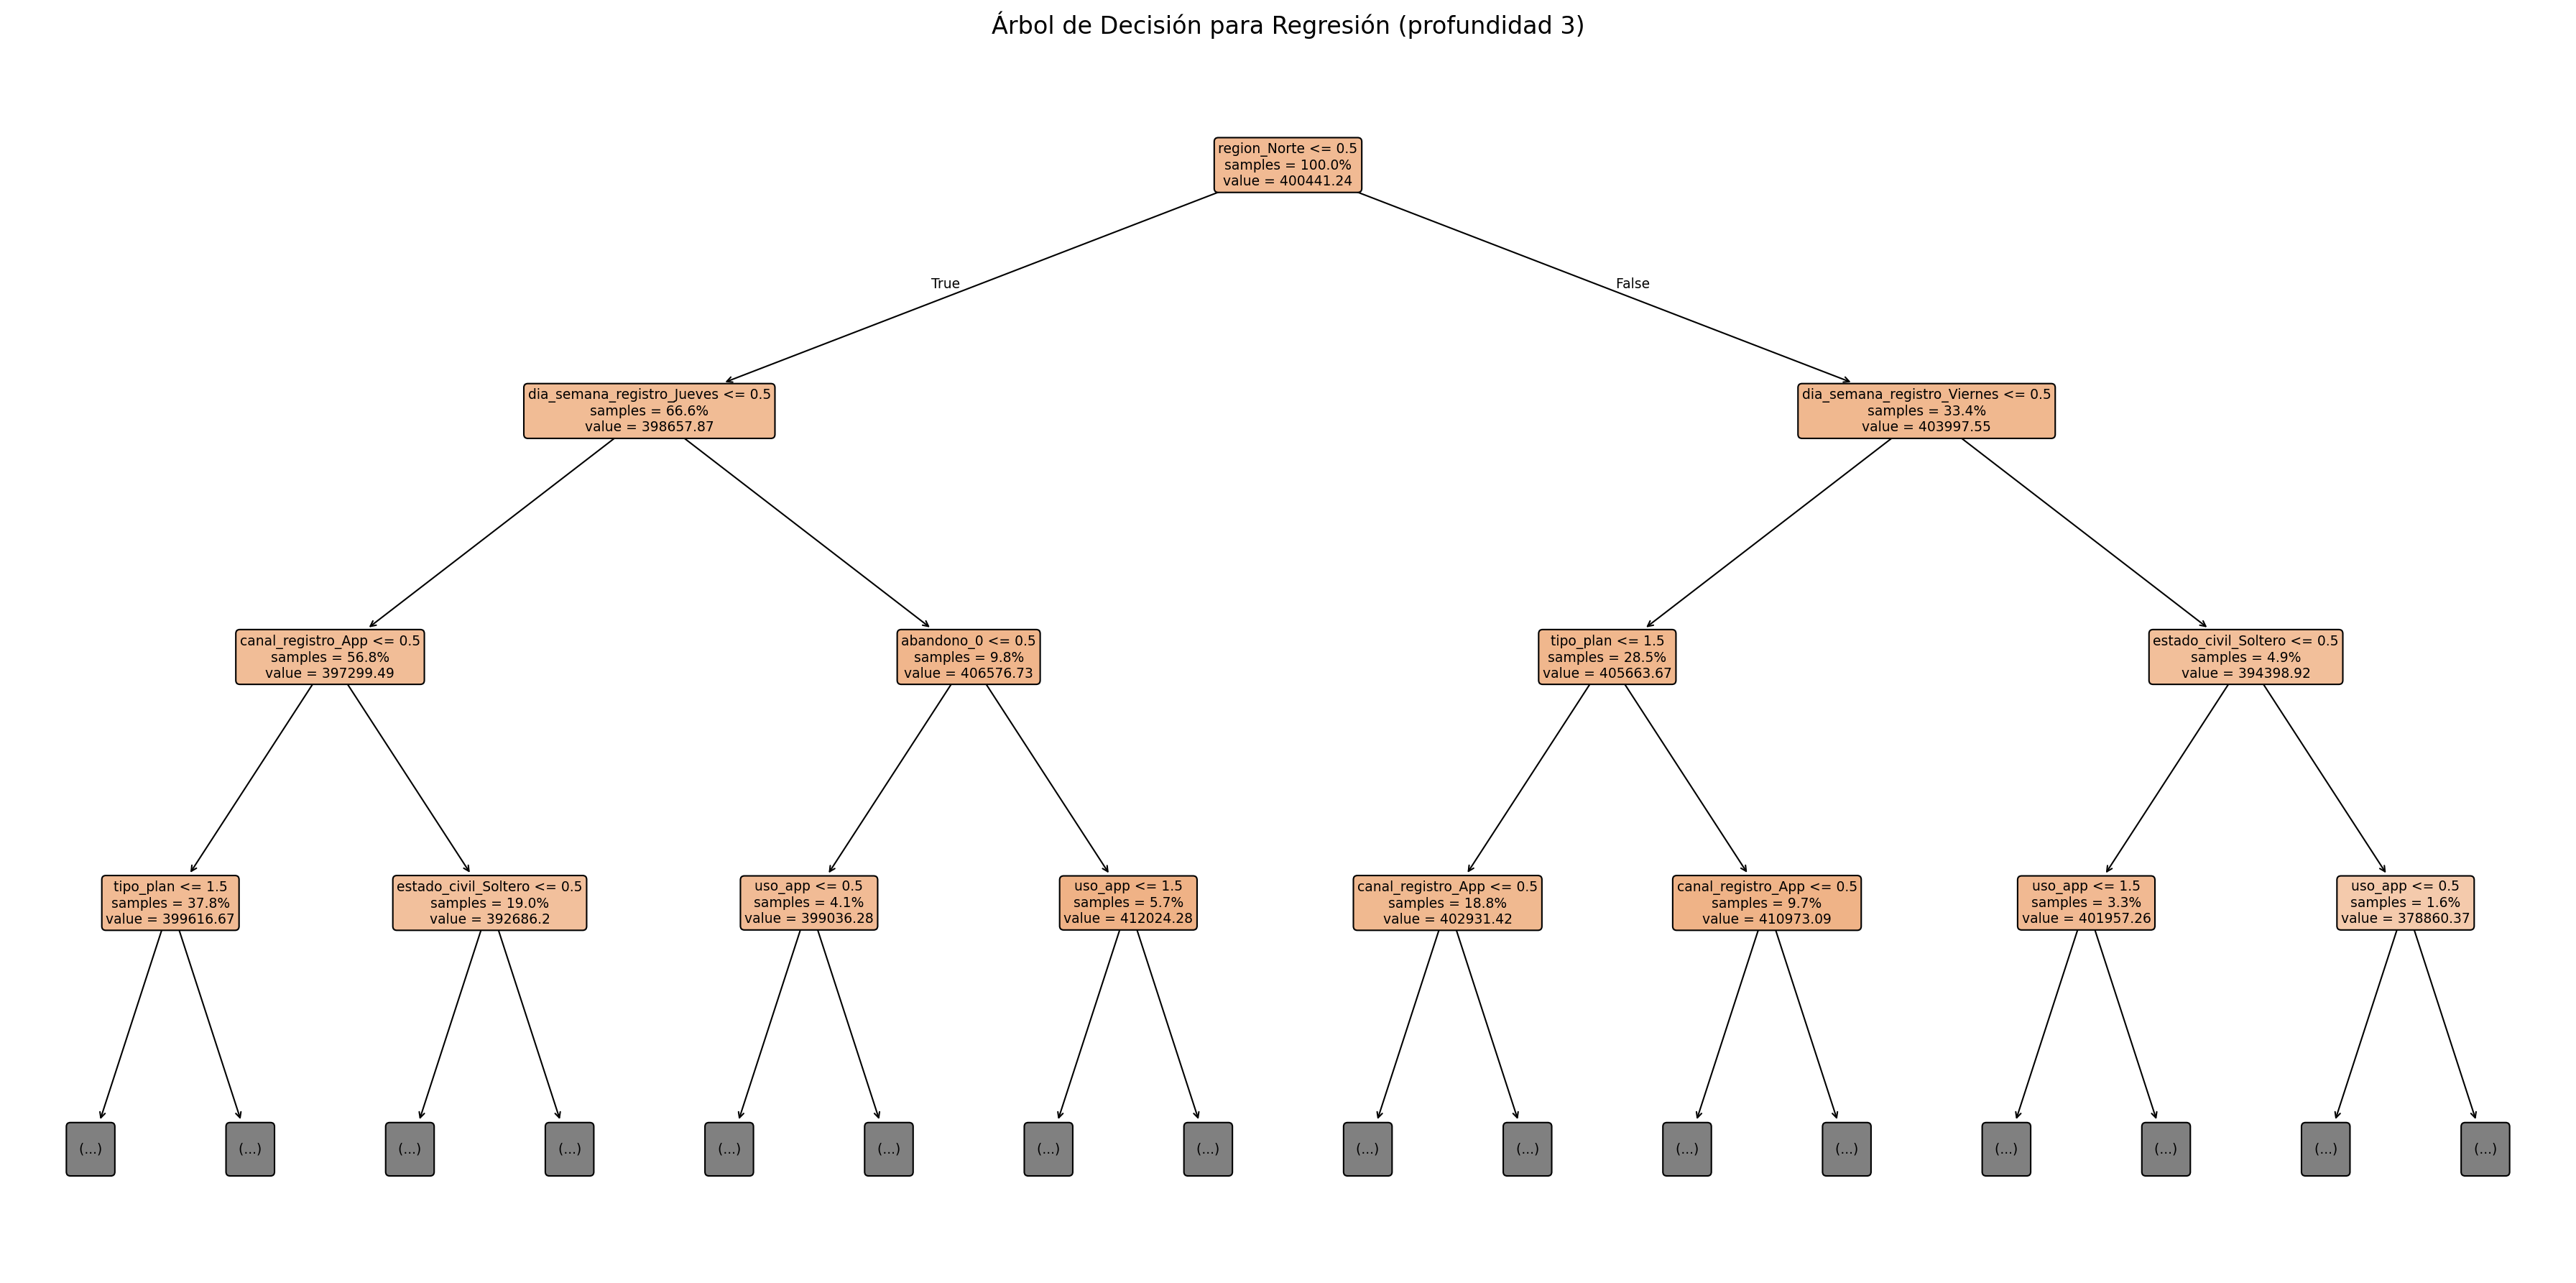

In [ ]:
modelo_arbol = DecisionTreeRegressor(max_depth=7, min_samples_leaf=15, random_state=42)
modelo_arbol = modelo_arbol.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(24, 12), dpi=150)
plot_tree(
    modelo_arbol,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3,
    impurity=False,
    proportion=True,
    precision=2,
    ax=ax,
 )

ax.set_title("Árbol de Decisión para Regresión (profundidad 3)", fontsize=16)
fig.tight_layout()
plt.show()

# 3. Modelamiento para variable objetivo "score_crediticio"

## Elimina duplicados y separa objetivo/features para mantener alineacion

In [ ]:
data_filtrada = eliminar_nulos_objetivo(data, target="score_crediticio")
data_sin_dup, var_dep, var_indep = separar_objetivo_features(
    data_filtrada,
    target="score_crediticio",
 )

In [ ]:
# Verifica que no haya nulos en la variable objetivo
var_dep.isna().sum()

np.int64(0)

## Construcción de arrays para procesamiento

In [ ]:
numerical_features = ["gasto_mensual", "deuda_total", "ingreso_mensual", "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias", "num_productos", "hora_registro"] # Define listado de variables numéricas.
categorical_nominales = ["abandono", "tiene_tarjeta_credito", "genero", "region", "estado_civil", "canal_registro", "dia_semana_registro"] # Define listado de variables categóricas nominales.
categorical_ordinales = ["tipo_plan", "uso_app"] # Define listado de variables categóricas ordinales.
date_time_features = ["fecha_registro"] # Define listado de variables de fecha y hora.
orden_tipo_plan = ["Basico", "Estandar", "Premium"] # Define orden para variable ordinal tipo_plan.
orden_uso_app = ["Bajo", "Medio", "Alto"] # Define orden para variable ordinal uso_app.

## Integración de pipelines de transformación

In [ ]:
pipeline_numerical_features, pipeline_nominales, pipeline_ordinales, preprocesador = build_preprocessor(
    numerical_features=numerical_features,
    categorical_nominales=categorical_nominales,
    categorical_ordinales=categorical_ordinales,
    orden_tipo_plan=orden_tipo_plan,
    orden_uso_app=orden_uso_app,
)

## Modelo de LinealRegression para "score_crediticio"

### Pipeline para Regresión Lineal

In [ ]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para regresión lineal.
pipeline_modelo_lr = build_linear_regression_pipeline()

In [ ]:
# Divide en train/test antes de ajustar el pipeline
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    var_indep, var_dep, test_size=0.3, random_state=29
)

# Ajusta el pipeline solo con train y transforma ambos conjuntos
X_train_t, X_test_t = aplicar_pipeline_limpieza_train_test(
    pipeline_limpieza, X_train_raw, X_test_raw
)

X_train_t.head()

,gasto_mensual,deuda_total,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,canal_registro_Web,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app
0,0.122664,0.237493,5.897906e-01,-0.253485,-0.968521,-1.643491,-1.621859,-0.000638,-1.075611,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.453893,0.452521,5.394070e-16,1.706635,-0.501448,1.104729,-0.415541,-0.000638,-0.203893,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.266499,-0.893368,-1.909805e-01,-0.981529,-1.377211,1.471159,-0.615011,0.707001,1.539544,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.871368,-0.077855,-9.433834e-02,-0.253485,-1.260442,0.921515,1.389185,-0.000638,-1.075611,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0
4,0.210456,-0.431833,2.072297e-01,-1.093536,1.045733,-1.643491,-1.298908,-0.000638,-1.511470,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [ ]:
target = "score_crediticio"
mejores_variables_predictoras = [
    "abandono_0",
    "abandono_1", 
    "hora_registro", 
    "frecuencia_compra", 
    "dia_semana_registro_Domingo",
    "ultima_compra_dias",
    "region_Sur",
    "region_Centro",
    "ingreso_mensual",
    "dia_semana_registro_Miercoles",
    "canal_registro_App",
    "edad"
 ]
X_train = X_train_t[mejores_variables_predictoras]
X_test = X_test_t[mejores_variables_predictoras]

### División train/test


In [ ]:
# El split ya se hizo antes del fit del pipeline
X_train.shape, X_test.shape

((13300, 12), (5700, 12))

### Entrenamiento


In [ ]:
pipeline_modelo_lr = entrenar_modelo(pipeline_modelo_lr, X_train, y_train)

In [ ]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_lr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['r2']:.3f}")
print(f"{'MAE':<6}: {metricas['mae']:,.0f}")


--- Métricas del modelo ---
R2    : 0.002
MAE   : 82


In [ ]:
# Variables que fueron eliminadas por presentar colinealidad
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
print(f"Variables eliminadas por colinealidad (n={len(cols_eliminadas)}):")
for col in cols_eliminadas:
    print(f"- {col}")

Variables eliminadas por colinealidad (n=1):
- abandono_1


In [ ]:
# Variables con las cuales fue entrenado el modelo
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
variables_usadas = [c for c in X_train.columns if c not in cols_eliminadas]

print(f"Variables usadas por el modelo (n={len(variables_usadas)}):")
for col in variables_usadas:
    print(f"- {col}")

Variables usadas por el modelo (n=11):
- abandono_0
- hora_registro
- frecuencia_compra
- dia_semana_registro_Domingo
- ultima_compra_dias
- region_Sur
- region_Centro
- ingreso_mensual
- dia_semana_registro_Miercoles
- canal_registro_App
- edad


## Modelo DecisionTreeRegressor para "score_crediticio"

### Pipeline para DecisionTreeRegressor

In [ ]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para DecisionTreeRegressor.
pipeline_modelo_dtr = build_decision_tree_regressor_pipeline(max_depth=7, min_samples_leaf=15, random_state=42)

In [ ]:
# Divide en train/test antes de ajustar el pipeline
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    var_indep, var_dep, test_size=0.3, random_state=29
)

# Ajusta el pipeline solo con train y transforma ambos conjuntos
X_train_t, X_test_t = aplicar_pipeline_limpieza_train_test(
    pipeline_limpieza, X_train_raw, X_test_raw
)

X_train_t.head()

,gasto_mensual,deuda_total,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,canal_registro_Web,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app
0,0.122664,0.237493,5.897906e-01,-0.253485,-0.968521,-1.643491,-1.621859,-0.000638,-1.075611,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.453893,0.452521,5.394070e-16,1.706635,-0.501448,1.104729,-0.415541,-0.000638,-0.203893,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.266499,-0.893368,-1.909805e-01,-0.981529,-1.377211,1.471159,-0.615011,0.707001,1.539544,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.871368,-0.077855,-9.433834e-02,-0.253485,-1.260442,0.921515,1.389185,-0.000638,-1.075611,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0
4,0.210456,-0.431833,2.072297e-01,-1.093536,1.045733,-1.643491,-1.298908,-0.000638,-1.511470,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [ ]:
target = "score_crediticio"
mejores_variables_predictoras = [
    "abandono_0",
    "abandono_1", 
    "hora_registro", 
    "frecuencia_compra", 
    "dia_semana_registro_Domingo",
    "ultima_compra_dias",
    "region_Sur",
    "region_Centro",
    "ingreso_mensual",
    "dia_semana_registro_Miercoles",
    "canal_registro_App",
    "edad"
 ]
X_train = X_train_t[mejores_variables_predictoras]
X_test = X_test_t[mejores_variables_predictoras]

### División train/test


In [ ]:
# El split ya se hizo antes del fit del pipeline
X_train.shape, X_test.shape

((13300, 12), (5700, 12))

### Entrenamiento

In [ ]:
pipeline_modelo_dtr = entrenar_modelo(pipeline_modelo_dtr, X_train, y_train)

In [ ]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_dtr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['r2']:.3f}")
print(f"{'MAE':<6}: {metricas['mae']:,.0f}")


--- Métricas del modelo ---
R2    : -0.041
MAE   : 83


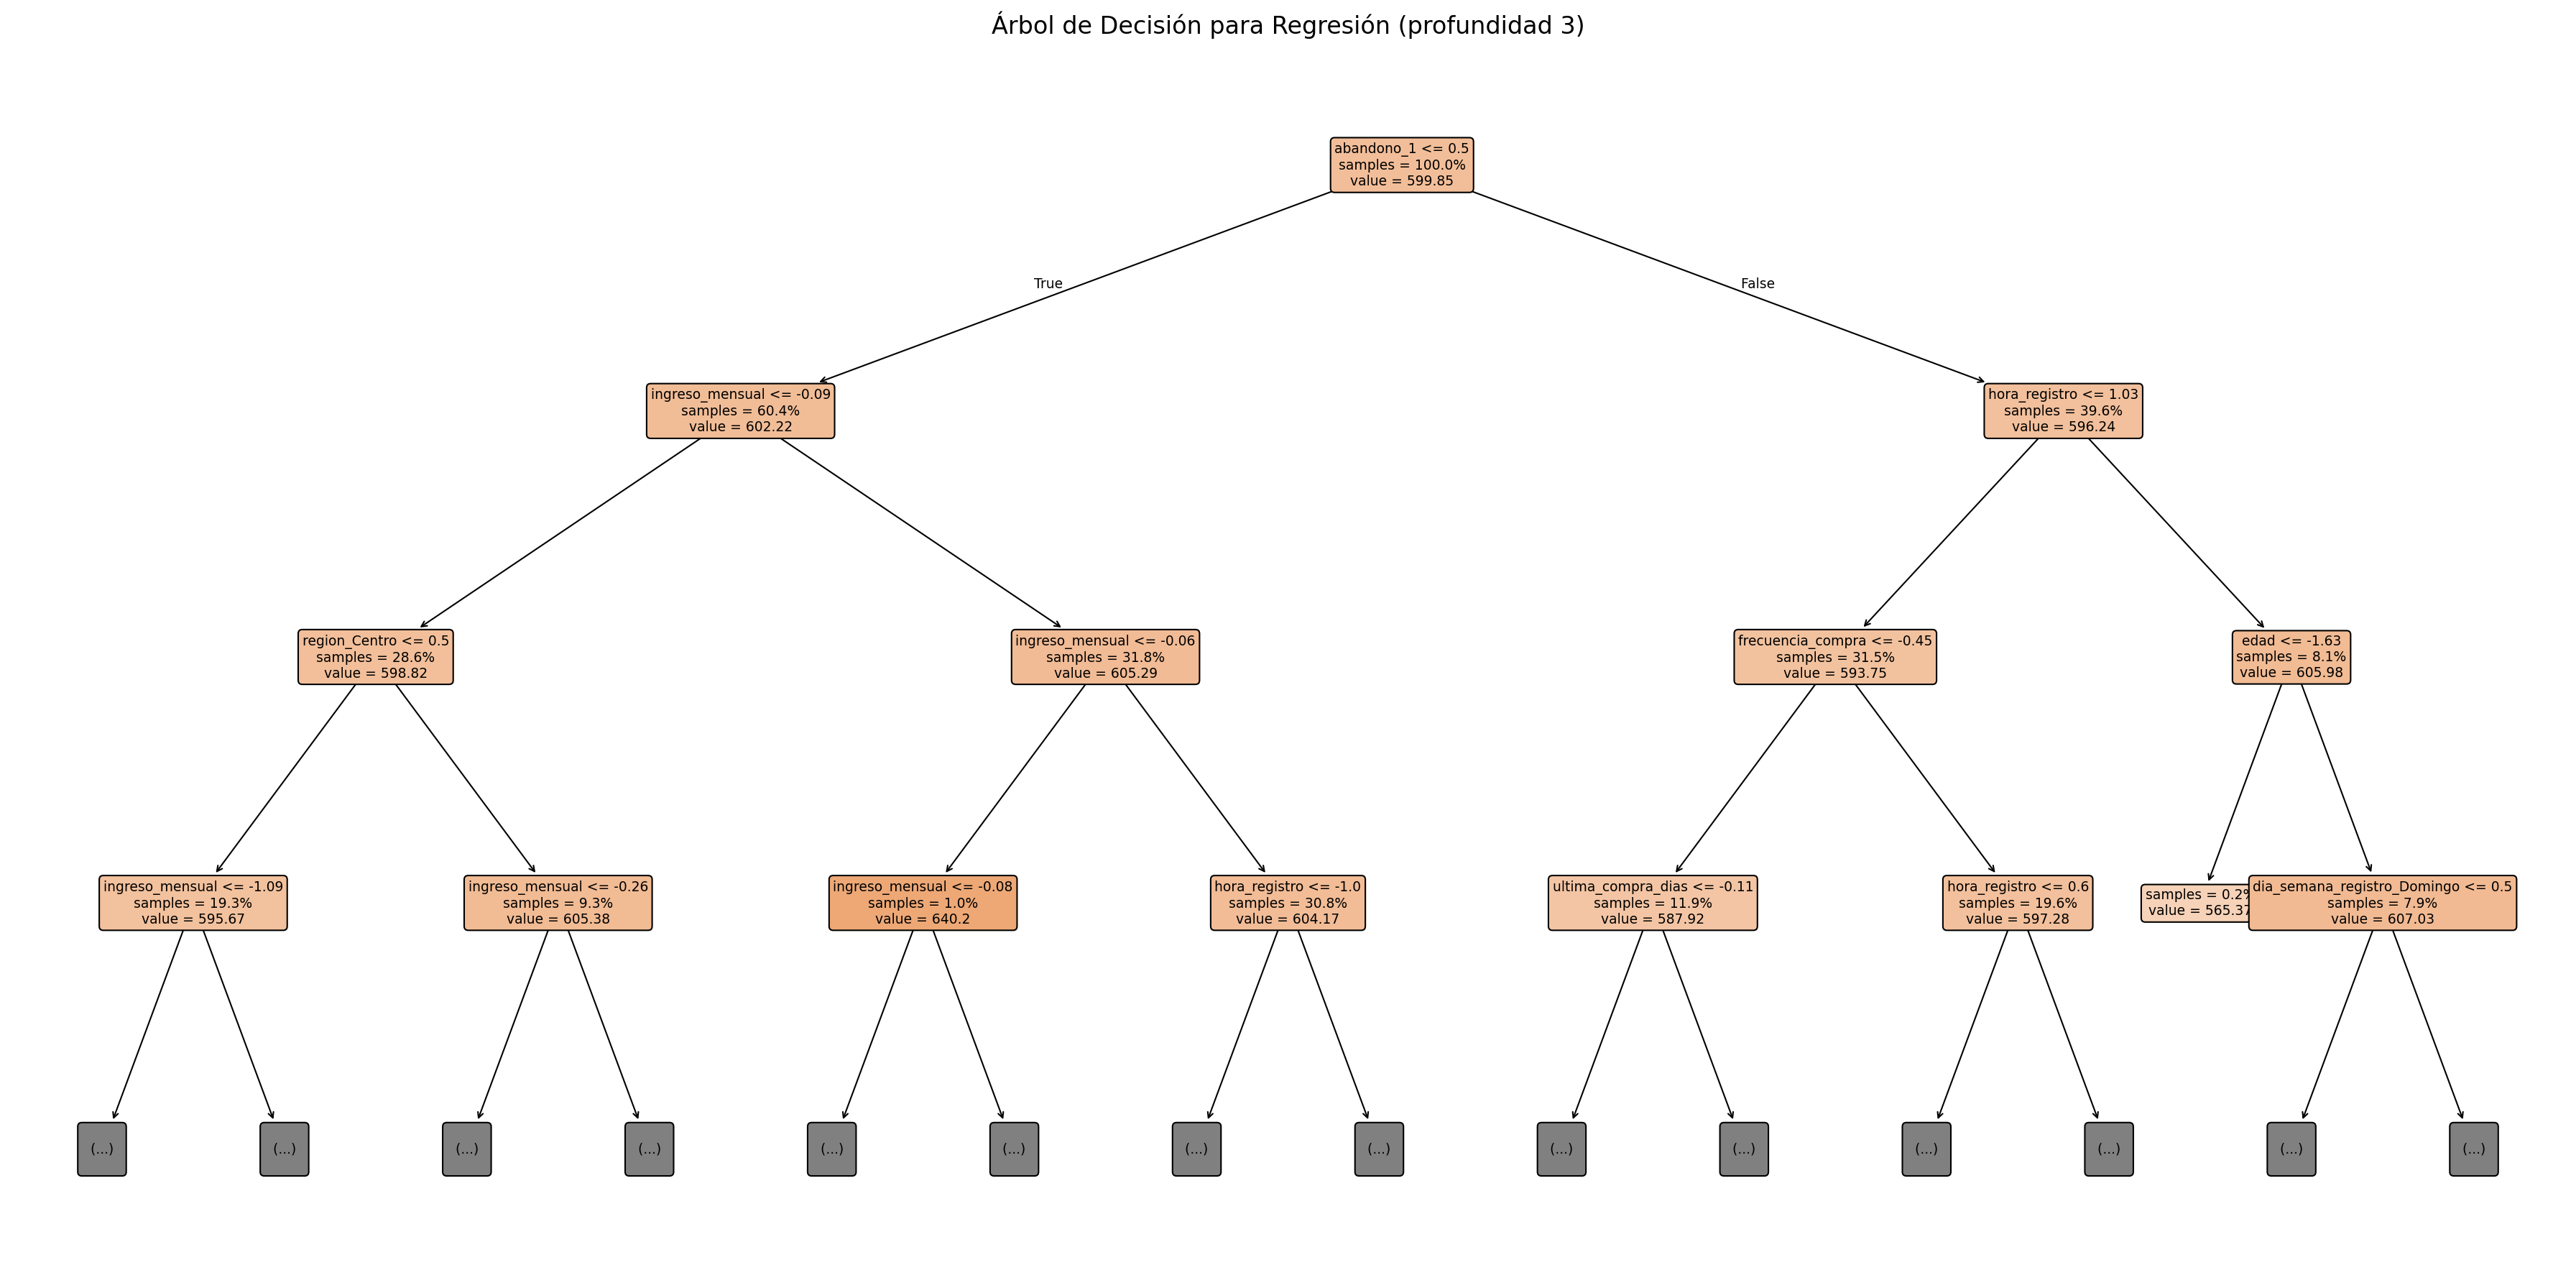

In [ ]:
modelo_arbol = DecisionTreeRegressor(max_depth=7, min_samples_leaf=15, random_state=42)
modelo_arbol = modelo_arbol.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(24, 12), dpi=150)
plot_tree(
    modelo_arbol,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3,
    impurity=False,
    proportion=True,
    precision=2,
    ax=ax,
 )

ax.set_title("Árbol de Decisión para Regresión (profundidad 3)", fontsize=16)
fig.tight_layout()
plt.show()

# 4. Modelamiento para variable objetivo "ingreso_mensual"

## Elimina duplicados y separa objetivo/features para mantener alineacion

In [ ]:
data_filtrada = eliminar_nulos_objetivo(data, target="ingreso_mensual")
data_sin_dup, var_dep, var_indep = separar_objetivo_features(
    data_filtrada,
    target="ingreso_mensual",
 )

In [ ]:
# Verifica que no haya nulos en la variable objetivo
var_dep.isna().sum()

np.int64(0)

## Construcción de arrays para procesamiento

In [ ]:
numerical_features = ["gasto_mensual", "deuda_total", "score_crediticio", "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias", "num_productos", "hora_registro"] # Define listado de variables numéricas.
categorical_nominales = ["abandono", "tiene_tarjeta_credito", "genero", "region", "estado_civil", "canal_registro", "dia_semana_registro"] # Define listado de variables categóricas nominales.
categorical_ordinales = ["tipo_plan", "uso_app"] # Define listado de variables categóricas ordinales.
date_time_features = ["fecha_registro"] # Define listado de variables de fecha y hora.
orden_tipo_plan = ["Basico", "Estandar", "Premium"] # Define orden para variable ordinal tipo_plan.
orden_uso_app = ["Bajo", "Medio", "Alto"] # Define orden para variable ordinal uso_app.

## Integración de pipelines de transformación

In [ ]:
pipeline_numerical_features, pipeline_nominales, pipeline_ordinales, preprocesador = build_preprocessor(
    numerical_features=numerical_features,
    categorical_nominales=categorical_nominales,
    categorical_ordinales=categorical_ordinales,
    orden_tipo_plan=orden_tipo_plan,
    orden_uso_app=orden_uso_app,
)

## Modelo de LinealRegression para "ingreso_mensual"

### Pipeline para Regresión Lineal

In [ ]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para regresión lineal.
pipeline_modelo_lr = build_linear_regression_pipeline()

In [ ]:
# Divide en train/test antes de ajustar el pipeline
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    var_indep, var_dep, test_size=0.3, random_state=29
)

# Ajusta el pipeline solo con train y transforma ambos conjuntos
X_train_t, X_test_t = aplicar_pipeline_limpieza_train_test(
    pipeline_limpieza, X_train_raw, X_test_raw
)

X_train_t.head()

,gasto_mensual,deuda_total,score_crediticio,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,canal_registro_Web,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app
0,1.409409,0.520205,0.287436,-0.086585,1.307227,-1.462733,-0.217267,1.427384,0.380160,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,2.0
1,0.547774,0.488423,1.160851,0.865414,-0.471195,1.662907,0.936757,1.427384,0.816296,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
2,-0.655306,-0.617914,0.000000,0.809414,-0.500350,0.192017,-0.226805,0.004760,0.380160,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
3,-0.904103,-0.710011,-1.266279,1.705414,0.899065,0.743601,0.297752,0.004760,1.688568,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.198491,-0.271834,-0.130581,0.697414,-1.229212,-1.462733,1.680673,0.004760,-0.055976,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
target = "ingreso_mensual"
mejores_variables_predictoras = [
    "tiene_tarjeta_credito_1",
    "tiene_tarjeta_credito_0", 
    "dia_semana_registro_Viernes", 
    "estado_civil_Casado", 
    "score_crediticio",
    "region_Centro"
 ]
X_train = X_train_t[mejores_variables_predictoras]
X_test = X_test_t[mejores_variables_predictoras]

### División train/test


In [ ]:
# El split ya se hizo antes del fit del pipeline
X_train.shape, X_test.shape

((13300, 6), (5700, 6))

### Entrenamiento


In [ ]:
pipeline_modelo_lr = entrenar_modelo(pipeline_modelo_lr, X_train, y_train)

In [ ]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_lr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['r2']:.3f}")
print(f"{'MAE':<6}: {metricas['mae']:,.0f}")


--- Métricas del modelo ---
R2    : -0.002
MAE   : 236,026


In [ ]:
# Variables que fueron eliminadas por presentar colinealidad
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
print(f"Variables eliminadas por colinealidad (n={len(cols_eliminadas)}):")
for col in cols_eliminadas:
    print(f"- {col}")

Variables eliminadas por colinealidad (n=1):
- tiene_tarjeta_credito_0


In [ ]:
# Variables con las cuales fue entrenado el modelo
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
variables_usadas = [c for c in X_train.columns if c not in cols_eliminadas]

print(f"Variables usadas por el modelo (n={len(variables_usadas)}):")
for col in variables_usadas:
    print(f"- {col}")

Variables usadas por el modelo (n=5):
- tiene_tarjeta_credito_1
- dia_semana_registro_Viernes
- estado_civil_Casado
- score_crediticio
- region_Centro


## Modelo DecisionTreeRegressor para "ingreso_mensual"

### Pipeline para DecisionTreeRegressor

In [ ]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para DecisionTreeRegressor.
pipeline_modelo_dtr = build_decision_tree_regressor_pipeline(max_depth=7, min_samples_leaf=15, random_state=42)

In [ ]:
# Divide en train/test antes de ajustar el pipeline
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    var_indep, var_dep, test_size=0.3, random_state=29
)

# Ajusta el pipeline solo con train y transforma ambos conjuntos
X_train_t, X_test_t = aplicar_pipeline_limpieza_train_test(
    pipeline_limpieza, X_train_raw, X_test_raw
)

X_train_t.head()

,gasto_mensual,deuda_total,score_crediticio,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,canal_registro_Web,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app
0,1.409409,0.520205,0.287436,-0.086585,1.307227,-1.462733,-0.217267,1.427384,0.380160,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,2.0
1,0.547774,0.488423,1.160851,0.865414,-0.471195,1.662907,0.936757,1.427384,0.816296,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
2,-0.655306,-0.617914,0.000000,0.809414,-0.500350,0.192017,-0.226805,0.004760,0.380160,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
3,-0.904103,-0.710011,-1.266279,1.705414,0.899065,0.743601,0.297752,0.004760,1.688568,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.198491,-0.271834,-0.130581,0.697414,-1.229212,-1.462733,1.680673,0.004760,-0.055976,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
target = "ingreso_mensual"
mejores_variables_predictoras = [
    "tiene_tarjeta_credito_1",
    "tiene_tarjeta_credito_0", 
    "dia_semana_registro_Viernes", 
    "estado_civil_Casado", 
    "score_crediticio",
    "region_Centro"
 ]
X_train = X_train_t[mejores_variables_predictoras]
X_test = X_test_t[mejores_variables_predictoras]

### División train/test


In [ ]:
# El split ya se hizo antes del fit del pipeline
X_train.shape, X_test.shape

((13300, 6), (5700, 6))

### Entrenamiento

In [ ]:
pipeline_modelo_dtr = entrenar_modelo(pipeline_modelo_dtr, X_train, y_train)

In [ ]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_dtr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['r2']:.3f}")
print(f"{'MAE':<6}: {metricas['mae']:,.0f}")


--- Métricas del modelo ---
R2    : -0.028
MAE   : 242,604


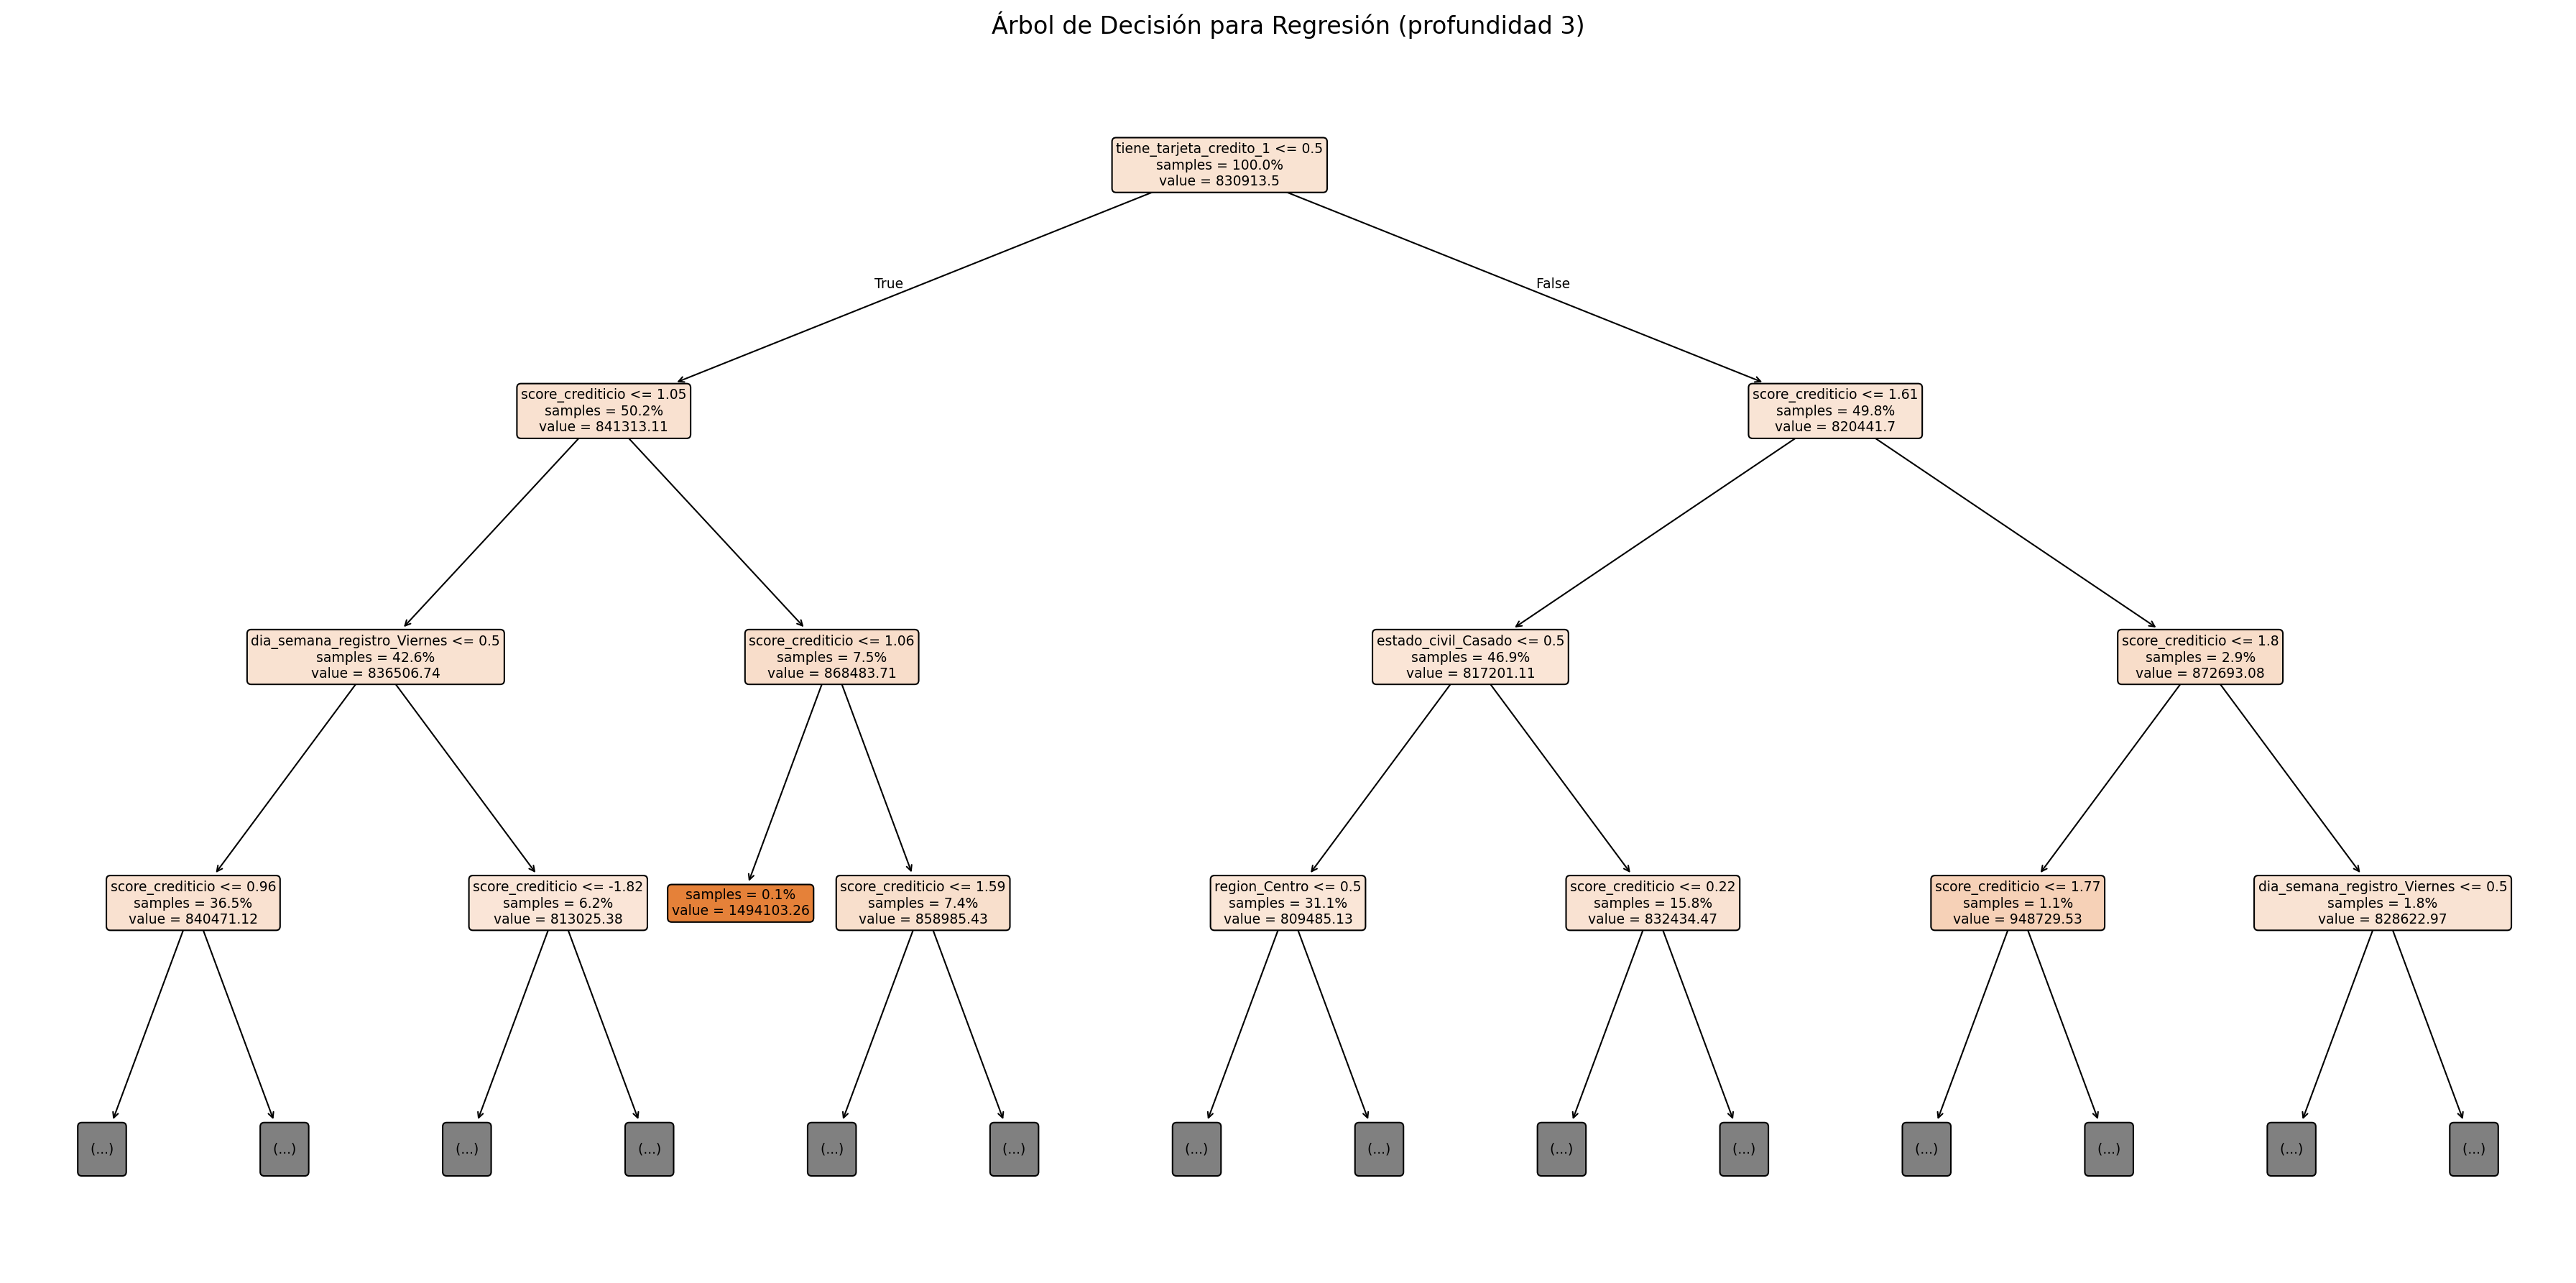

In [ ]:
modelo_arbol = DecisionTreeRegressor(max_depth=7, min_samples_leaf=15, random_state=42)
modelo_arbol = modelo_arbol.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(24, 12), dpi=150)
plot_tree(
    modelo_arbol,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3,
    impurity=False,
    proportion=True,
    precision=2,
    ax=ax,
 )

ax.set_title("Árbol de Decisión para Regresión (profundidad 3)", fontsize=16)
fig.tight_layout()
plt.show()